In [1]:
from pathlib import Path
import argparse
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
from torch.nn.utils.rnn import pad_sequence
from sklearn.cluster import AgglomerativeClustering
from Bio import Phylo, SeqIO
from triton.language import bfloat16
from scipy.stats import pearsonr, spearmanr
import json
import itertools
import logging

import hydra
from hydra import compose, initialize
import models
from collections import OrderedDict
import noise_schedule

import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, FormatStrFormatter, FuncFormatter
import ast
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from guaidance_regressor_all_data import FirstTokenAttention_genome, RegressionHead, load_all_genome_embeddings, load_text_wo_genome_embeddings
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors  # 仅用于颜色处理

import selfies as sf
from IPython.core.display import display, HTML
import matplotlib

current_directory = Path('/data2/tianang/projects/Synergy')

with initialize(config_path="configs"):
    config = compose(config_name="config")

class mol_emb_mdlm(nn.Module):
    def __init__(self, config, vocab_size, ckpt_path):
        super(mol_emb_mdlm, self).__init__()
        self.config = config
        self.vocab_size = vocab_size
        self.ckpt_path = ckpt_path
        self.parameterization = self.config.parameterization
        self.time_conditioning = self.config.time_conditioning
        self.backbone = self.load_DIT()  # hidden_size = 768
        # print(self.bert.config.max_position_embeddings)
        self.noise = noise_schedule.get_noise(self.config)

    def _process_sigma(self, sigma):
        if sigma is None:
            assert self.parameterization == 'ar'
            return sigma
        if sigma.ndim > 1:
            sigma = sigma.squeeze(-1)
        if not self.time_conditioning:
            sigma = torch.zeros_like(sigma)
        assert sigma.ndim == 1, sigma.shape
        return sigma

    def _sample_t(self, n, device):
        sampling_eps = 1e-3
        _eps_t = torch.rand(n, device=device)
        t = (1 - sampling_eps) * _eps_t + sampling_eps
        return t * 0

    def _forward(self, x, sigma):
        sigma = self._process_sigma(sigma)
        with torch.cuda.amp.autocast(dtype=torch.float32):
            x = self.backbone.vocab_embed(x)
            c = F.silu(self.backbone.sigma_map(sigma))
            rotary_cos_sin = self.backbone.rotary_emb(x)

            with torch.cuda.amp.autocast(dtype=torch.bfloat16):
                for i in range(len(self.backbone.blocks)):
                    x = self.backbone.blocks[i](x, rotary_cos_sin, c, seqlens=None)

        return x


    def forward(self, input_ids, attention_mask=None):
        t = self._sample_t(input_ids.shape[0], input_ids.device)
        sigma, dsigma = self.noise(t)
        unet_conditioning = sigma[:, None]
        outputs = self._forward(input_ids, unet_conditioning)
        return outputs

    def load_DIT(self):
        backbone = models.dit.DIT(self.config, vocab_size=self.vocab_size)
        lightning_ckpt = torch.load(self.ckpt_path, map_location='cpu')
        state_dict = lightning_ckpt['state_dict']

        new_sd = OrderedDict()
        for k, v in state_dict.items():
            if k.startswith('backbone.'):
                new_key = k[len('backbone.'):]
            else:
                new_key = k
            new_sd[new_key] = v

        backbone.load_state_dict(new_sd, strict=False)

        return backbone

class mol_emb_mdlm_no_weights(mol_emb_mdlm):
    """
    重写 load_DIT 的部分消去对路径的依赖
    """
    def __init__(self, config, vocab_size):
        super().__init__(config, vocab_size, ckpt_path=None)

    def load_DIT(self):
        backbone = models.dit.DIT(self.config, vocab_size=self.vocab_size)
        return backbone


class MIC_regressor(nn.Module):
    """
    融合了 mdlm 和所有的 genome text emb 的部分
    """

    def __init__(self, config, ckpt_path, device):
        super(MIC_regressor, self).__init__()
        self.config = config
        # self.strain_cond = strain_cond
        self.ckpt_path = ckpt_path
        self.device = device
        self.mdlm_model: nn.Module = mol_emb_mdlm_no_weights(config, len(tokenizer.get_vocab()))
        self.co_cross_attn_genome = FirstTokenAttention_genome(self.mdlm_model.config.model.hidden_size, 8192, 4, 0.1)
        self.co_cross_attn_text = FirstTokenAttention_genome(self.mdlm_model.config.model.hidden_size, 4096, 4, 0.1)
        self.reg_head = RegressionHead(8192 + 4096, (8192 + 4096) // 4, 128, 1, 0.2)
        self.cls_head = RegressionHead(8192 + 4096, (8192 + 4096) // 4, 128, 1, 0.2)
        self.learnable_embedding_weight = nn.Parameter(torch.randn(1, 8192, device=device))
        self.load_pretrained_weight()

        self.ATCC_genome_emb_dict, self.ATCC_text_emb_dict, self.text_only_emb_dict = self.load_genome_test_embedding()

    def load_genome_test_embedding(self):
        ATCC_genome_emb_dict = load_all_genome_embeddings(
            Path(current_directory/'DataPrepare'/'Data'/'Genome_embs'),
            1e14,
            'cpu',
            'ATCC genome embedding')
        ATCC_text_emb_dict = load_all_genome_embeddings(
            Path(current_directory/'DataPrepare'/'Data'/'Text_Description'/'ATCC'/'embeddings'),
            1,
            'cpu',
            'ATCC text embedding')
        text_only_emb_dict = load_text_wo_genome_embeddings(
            Path(current_directory/'DataPrepare'/'Data'/'Text_Description'/'wo_ATCC'/'embeddings'),
            1,
            'cpu',
            'text only embedding')
        return ATCC_genome_emb_dict, ATCC_text_emb_dict, text_only_emb_dict

    def load_pretrained_weight(self):
        """
        在使用 forward 之前进行，load 自己要用的权重
        """
        regressor_ckpt_path = self.ckpt_path
        checkpoint = torch.load(regressor_ckpt_path, map_location=self.device)
        # new_sd = OrderedDict()
        # for k, v in checkpoint['mdlm_model_state_dict'].items():
        #     if k.startswith('backbone.'):
        #         new_key = k[len('backbone.'):]
        #     else:
        #         new_key = k
        #     new_sd[new_key] = v
        self.mdlm_model.load_state_dict(checkpoint['mdlm_model_state_dict'])
        self.reg_head.load_state_dict(checkpoint['re_head_state_dict'])
        self.cls_head.load_state_dict(checkpoint['cls_head_state_dict'])
        self.co_cross_attn_genome.load_state_dict(checkpoint['co_cross_attn_genome'])
        self.co_cross_attn_text.load_state_dict(checkpoint['co_cross_attn_text'])
        self.learnable_embedding_weight = checkpoint['learnable_embedding_weight']

    def forward(self, input_ids: torch.Tensor, strain_cond):
        output = self.mdlm_model(input_ids)
        mol_cls_embedding = output[:, 0, :]
        if strain_cond in self.ATCC_genome_emb_dict.keys():
            padded_genome_embeddings = self.ATCC_genome_emb_dict[strain_cond].to(device)
            padded_text_embeddings = self.ATCC_text_emb_dict[strain_cond].to(device)
            padded_genome_embeddings = padded_genome_embeddings[None, ...].expand(mol_cls_embedding.shape[0], -1, -1)
            genome_attn_masks = torch.ones(padded_genome_embeddings.shape[0], padded_genome_embeddings.shape[1]).to(device)
        else:
            padded_genome_embeddings = None
            padded_text_embeddings = self.text_only_emb_dict[strain_cond].to(device)
        padded_text_embeddings = padded_text_embeddings[None, ...].expand(mol_cls_embedding.shape[0], -1, -1)
        text_attn_masks = torch.ones(padded_text_embeddings.shape[0], padded_text_embeddings.shape[1]).to(device)

        with torch.cuda.amp.autocast(dtype=torch.bfloat16):
            if padded_genome_embeddings is not None:
                mol_cls_embedding_genome, attn_genome = self.co_cross_attn_genome(mol_cls_embedding, padded_genome_embeddings, 1 - genome_attn_masks)
            else:
                padded_genome_embeddings = self.learnable_embedding_weight[:, None, :].expand(mol_cls_embedding.shape[0], 1, -1)
                genome_attn_masks = torch.from_numpy(np.array([1]))[None, :].expand(mol_cls_embedding.shape[0], -1)
                mol_cls_embedding_genome, attn_genome = self.co_cross_attn_genome(mol_cls_embedding, padded_genome_embeddings, 1 - genome_attn_masks)
            mol_cls_embedding_text, attn_text = self.co_cross_attn_text(mol_cls_embedding, padded_text_embeddings, 1 - text_attn_masks)
            mol_cls_embedding = torch.cat((mol_cls_embedding_genome.reshape(-1, 8192), mol_cls_embedding_text.reshape(-1, 4096)), dim=1)
            reg_logits = self.reg_head(mol_cls_embedding)
            cls_output = torch.sigmoid(self.cls_head(mol_cls_embedding))

        return reg_logits, cls_output, attn_genome, attn_text

def get_mic(file_path, mic_regressor, tokenizer, strain):
    # for file_name in file_names:
    #     file_strain = file_name.split('.txt')[0].split('_')[1]
    #     file_target_MIC = file_name.split('.txt')[0].split('_')[3]
    #     try:
    #         file_guidance_method = file_name.split('.txt')[0].split('_')[-1]
    #         file_target_length = file_name.split('.txt')[0].split('_')[5]
    #     except:
    #         continue
    #     if strain == file_strain and file_target_MIC == target_MIC and file_guidance_method == guidance_method and file_target_length == target_length:
    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()  # 返回所有行的列表，每行末尾包含 '\n'
    # 如果想去掉末尾的换行符：
    SELFIES_strs = [sf.encoder(line.rstrip("\n")) for line in lines]

    input_ids = tokenizer(
        [s.replace('][', '] [') for s in SELFIES_strs],
        return_tensors='pt',
        padding=True,
        truncation=False,
        add_special_tokens=True
    )['input_ids'].to(device)

    mics = []
    cls_outputs = []
    i=0
    step_size = 1  # 1 / 100
    while i<len(input_ids):

        batch_input_ids = input_ids[i:i+step_size]
        if step_size == 1:
            batch_input_ids = batch_input_ids[batch_input_ids!=tokenizer.pad_token_id].unsqueeze(0)
        mic_logits, cls_output, attn_genome, attn_text = mic_regressor(batch_input_ids, strain)
        mic_logits = mic_logits.squeeze().detach()
        cls_output = cls_output.squeeze().detach()
        mic = 10 ** (-mic_logits) * 10

        if step_size == 1:
            mic = mic.cpu().to(torch.float)
        mics.append(mic)

        if step_size == 1:
            cls_output = cls_output.cpu().to(torch.float)
        cls_outputs.append(cls_output)

        i += step_size

    if step_size != 1:
        mics = torch.concat(mics, dim = 0)
    else:
        mics = torch.from_numpy(np.array(mics))

    if step_size != 1:
        cls_outputs = torch.concat(cls_outputs, dim = 0)
    else:
        cls_outputs = torch.from_numpy(np.array(cls_outputs))

    return mics, cls_outputs, attn_genome, attn_text

/data2/tianang/projects/mdlm/guaidance_regressor_all_data.py:35: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="configs"):
/tmp/ipykernel_2559421/4131948704.py:40: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML
/tmp/ipykernel_2559421/4131948704.py:45: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="configs"):


 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:01<00:00, 568.96it/s]


mic:tensor([0.0542])


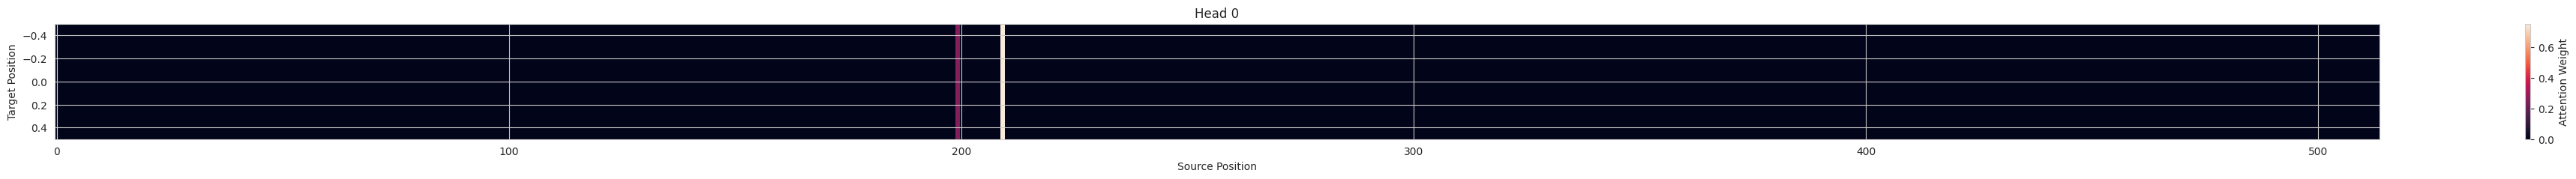

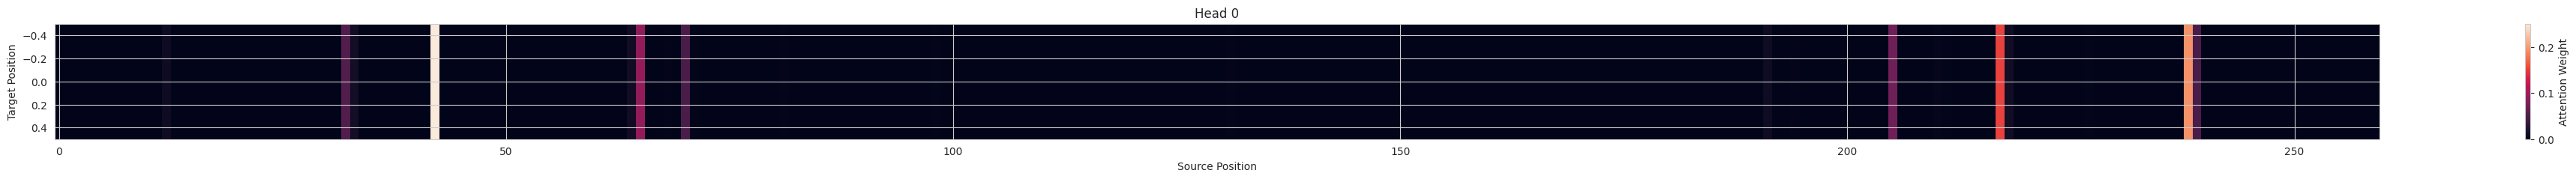

/tmp/ipykernel_1163357/4020493308.py:92: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [3]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['25922']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'DBAASP_2015.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Head {head}")
        plt.imshow(attn_genome[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (current_directory/'DataPrepare'/'Data'/'Text_Description'/'ATCC'/'Text').iterdir():
        if strains[0] in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

/tmp/ipykernel_1128137/2905929900.py:40: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML
/tmp/ipykernel_1128137/2905929900.py:45: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="configs"):
 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:01<00:00, 568.69it/s]
Token indices sequence length is longer than the specified maximum sequence length for this model (639 > 512). Running this sequence through the model will result in indexing errors


mic:tensor([22.2500])


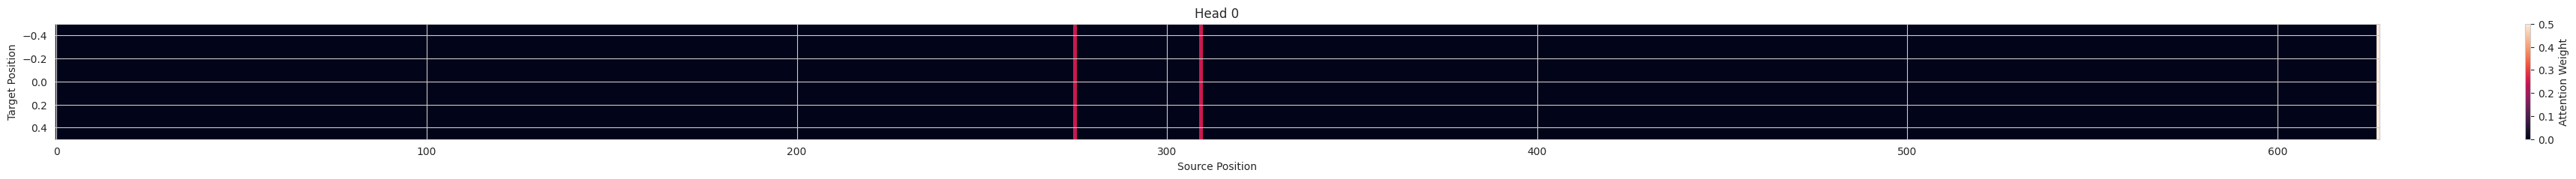

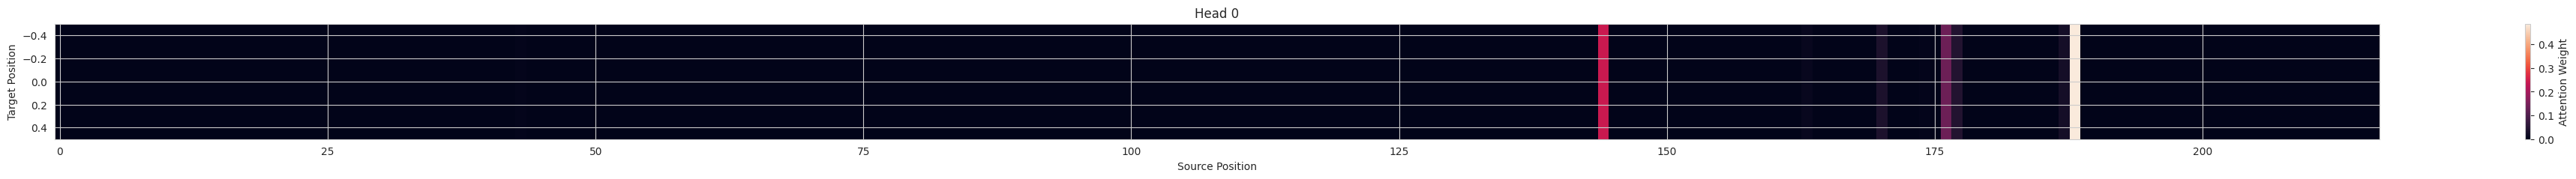

/tmp/ipykernel_1128137/2905929900.py:352: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [11]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['47085']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'DBAASP_9115.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Head {head}")
        plt.imshow(attn_genome[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (current_directory/'DataPrepare'/'Data'/'Text_Description'/'ATCC'/'Text').iterdir():
        if strains[0] in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

/tmp/ipykernel_1128137/274589238.py:40: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML
/tmp/ipykernel_1128137/274589238.py:45: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path="configs"):
 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:01<00:00, 888.74it/s]


mic:tensor([478.])


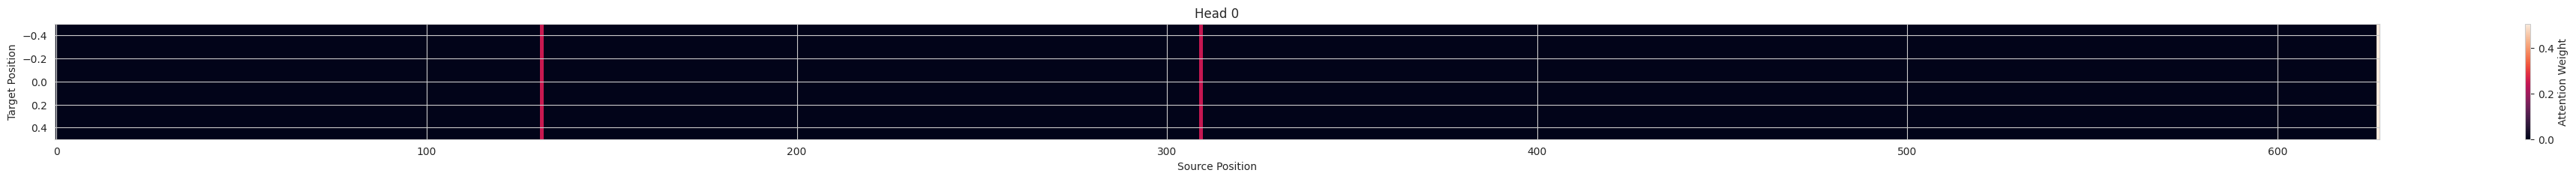

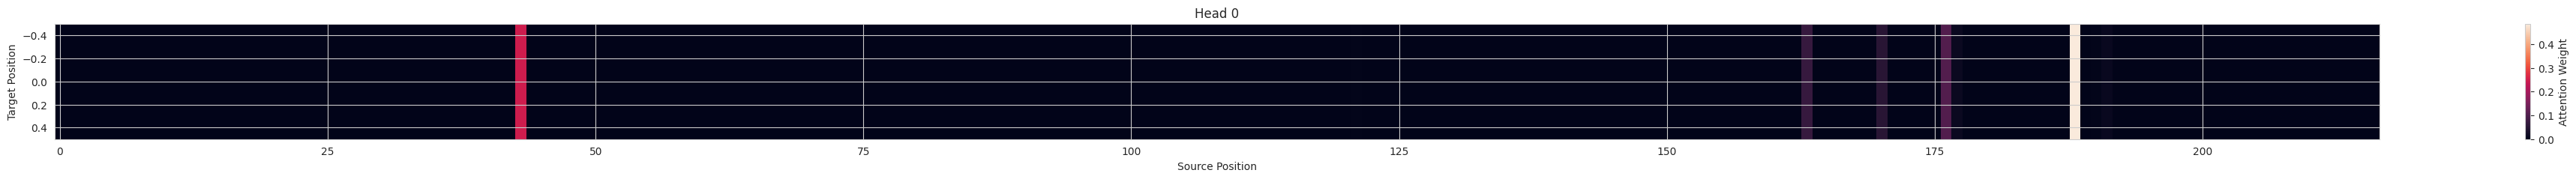

/tmp/ipykernel_1128137/274589238.py:352: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [13]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['47085']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'DBAASP_10403.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Head {head}")
        plt.imshow(attn_genome[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (current_directory/'DataPrepare'/'Data'/'Text_Description'/'ATCC'/'Text').iterdir():
        if strains[0] in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:01<00:00, 951.32it/s]


mic:tensor([0.0100])


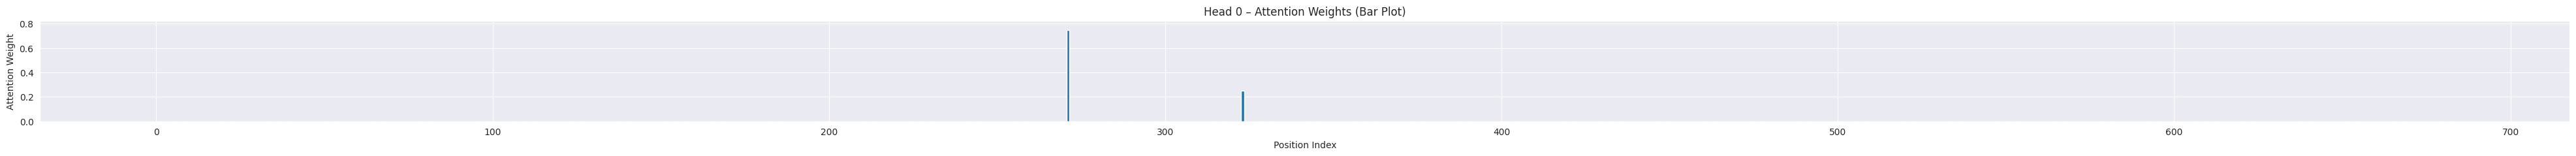

 big attn scores: [0.75 0.25]
 corresponding index: [271 323]


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



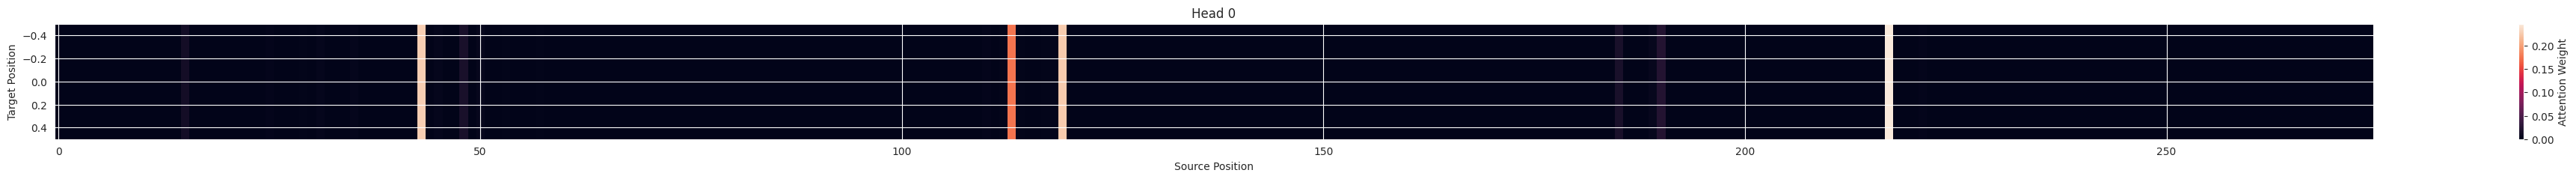

/tmp/ipykernel_1163357/711533916.py:120: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [16]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['27853']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'DBAASP_349_27853.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index*10000, big_attn_index*10000+11000])

    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain in annotation_file.name:
            break

    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        for feature in seq_record.features:
            if feature.type == 'gene':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if int(feature.location.start)>big_attn_gene_range[0] and int(feature.location.end)<big_attn_gene_range[1]:
                        print(seq_record.features)



    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (current_directory/'DataPrepare'/'Data'/'Text_Description'/'ATCC'/'Text').iterdir():
        if strains[0] in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

In [9]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['47085']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'DBAASP_9115.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain in annotation_file.name:
            break

    attented_products = []
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
    print(f" attended products:\n{attented_products}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0] in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:01<00:00, 1058.30it/s]
Token indices sequence length is longer than the specified maximum sequence length for this model (639 > 512). Running this sequence through the model will result in indexing errors


ValueError: too many values to unpack (expected 3)

#### ApexOracle-3 对于 BAA-3197 耐药性解释

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:02<00:00, 447.67it/s]


mic:tensor([10.5625])
cls:tensor([0.5156])


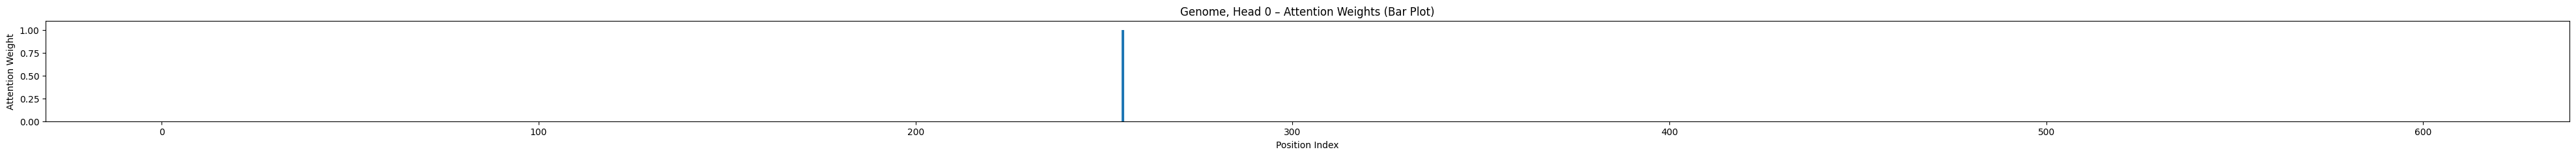

 big attn scores: [1.]
 corresponding index: [255]
 config_id:assembly_cedbec140e354d0a_1
 config_id:assembly_cedbec140e354d0a_2
 config_id:assembly_cedbec140e354d0a_3
 attended products:
['DUF3275 family protein', 'DUF932 domain-containing protein', 'DUF3577 domain-containing protein', 'GTPase', 'uridylate kinase', 'ABC transporter substrate-binding protein']
 attended genes:
['None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None']


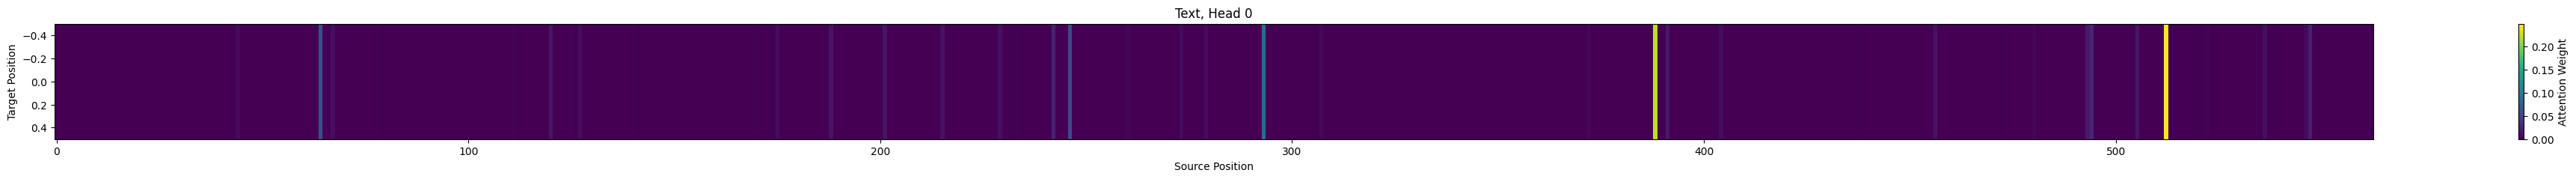

Text file loaded:/data2/tianang/projects/Synergy/DataPrepare/Data/Text_Description/ATCC/Text/Pseudomonas_aeruginosa_ATCC_BAA_3197.txt


/tmp/ipykernel_2668758/2472198865.py:160: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [9]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/all_AMP_SM_data_train/MDLM_MTR_fix_cls_wo_pad/all_data_best_R2_epoch_13.pth'  # 这个权重在所有的 MIC data 上训练过
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['BAA-3197']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'ApexOracle_3.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, cls_outputs, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')
    print(f'cls:{cls_outputs}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Genome, Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    annotation_found_flag = False
    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain.replace('-','_') in annotation_file.name:
            annotation_found_flag = True
            break

    if not annotation_found_flag:
        print(f'genome annotation for {strain} not found')
        exit(1)

    attented_products = []
    attented_genes = []
    contig_lengths = []
    current_contig_id = 0
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        config_id = int(seq_record.id.split('_')[-1])
        print(f' config_id:{seq_record.id}')
        if config_id != current_contig_id:
            current_contig_id = config_id
            contig_lengths.append(len(seq_record.seq))

        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if config_id > 1:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0] - np.array(contig_lengths).sum(), big_attn_gene_range[1] - np.array(contig_lengths).sum()
                    else:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0], big_attn_gene_range[1]
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')  # feature.qualifiers.get('gene / product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
                        genes = feature.qualifiers.get('gene')  # feature.qualifiers.get('gene / product')
                        if genes is not None:
                            for gene in genes:
                                if 'hypothetical' not in gene:
                                    attented_genes.append(gene)
                        else:
                            attented_genes.append('None')
    print(f" attended products:\n{attented_products}")
    print(f" attended genes:\n{attented_genes}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Text, Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0].replace('-', '_') in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        # text = text.replace(file_name.replace('_', ' ').replace('BAA ', 'BAA-'), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
print(f'Text file loaded:{str(text_file_path)}')
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

#### ApexOracle-3 对于 BAA-47085 (PAO1) 耐药性解释

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:02<00:00, 405.15it/s]


mic:tensor([37.5000])
cls:tensor([0.5000])


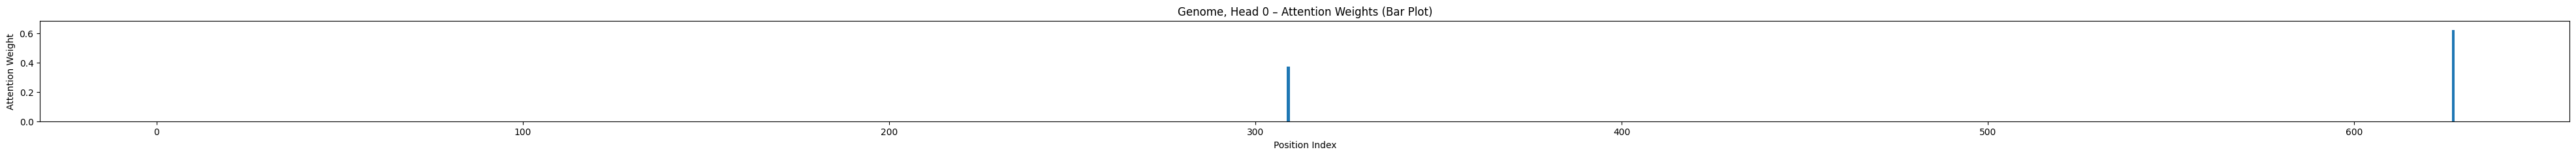

 big attn scores: [0.37500003 0.625     ]
 corresponding index: [309 627]
 config_id:assembly_a6462b6cc7da4347_1
 config_id:assembly_a6462b6cc7da4347_2
 config_id:assembly_a6462b6cc7da4347_3
 attended products:
['RhuM family protein', 'RhuM family protein', 'restriction endonuclease subunit S', 'class I SAM-dependent DNA methyltransferase', 'helix-turn-helix domain-containing protein', 'MerR family transcriptional regulator', 'integration host factor subunit alpha', 'phenylalanine--tRNA ligase subunit beta', 'membrane protein insertase YidC', 'ribonuclease P protein component', '50S ribosomal protein L34']
 attended genes:
['rhuM', 'rhuM', 'None', 'None', 'None', 'None', 'ihfA', 'pheT', 'yidC', 'rnpA', 'rpmH']


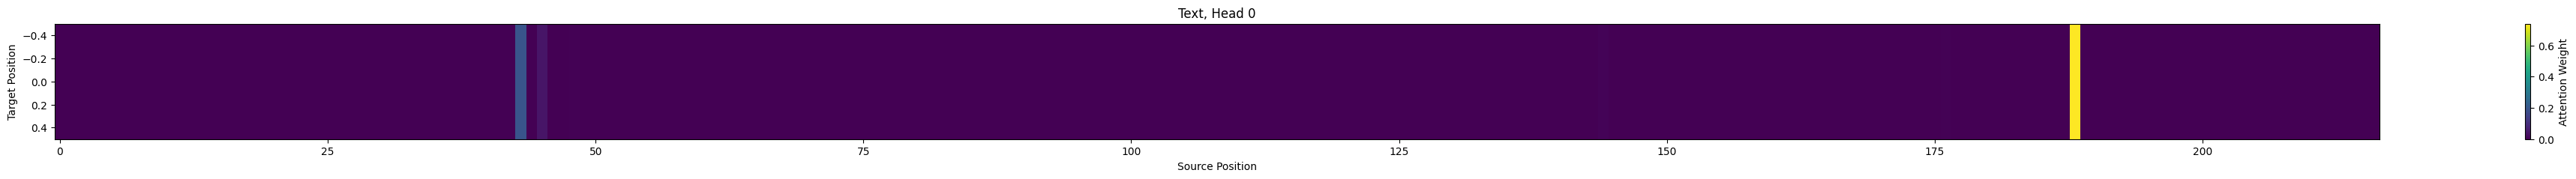

Text file loaded:/data2/tianang/projects/Synergy/DataPrepare/Data/Text_Description/ATCC/Text/Pseudomonas_aeruginosa_ATCC_47085.txt


/tmp/ipykernel_2668758/3715342688.py:160: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [14]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/all_AMP_SM_data_train/MDLM_MTR_fix_cls_wo_pad/all_data_best_R2_epoch_13.pth'  # 这个权重在所有的 MIC data 上训练过
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['47085']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'ApexOracle_3.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, cls_outputs, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')
    print(f'cls:{cls_outputs}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Genome, Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    annotation_found_flag = False
    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain.replace('-','_') in annotation_file.name:
            annotation_found_flag = True
            break

    if not annotation_found_flag:
        print(f'genome annotation for {strain} not found')
        exit(1)

    attented_products = []
    attented_genes = []
    contig_lengths = []
    current_contig_id = 0
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        config_id = int(seq_record.id.split('_')[-1])
        print(f' config_id:{seq_record.id}')
        if config_id != current_contig_id:
            current_contig_id = config_id
            contig_lengths.append(len(seq_record.seq))

        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if config_id > 1:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0] - np.array(contig_lengths).sum(), big_attn_gene_range[1] - np.array(contig_lengths).sum()
                    else:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0], big_attn_gene_range[1]
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')  # feature.qualifiers.get('gene / product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
                        genes = feature.qualifiers.get('gene')  # feature.qualifiers.get('gene / product')
                        if genes is not None:
                            for gene in genes:
                                if 'hypothetical' not in gene:
                                    attented_genes.append(gene)
                        else:
                            attented_genes.append('None')
    print(f" attended products:\n{attented_products}")
    print(f" attended genes:\n{attented_genes}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Text, Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0].replace('-', '_') in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        # text = text.replace(file_name.replace('_', ' ').replace('BAA ', 'BAA-'), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
print(f'Text file loaded:{str(text_file_path)}')
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

#### ApexOracle-3 对于 PA14 (ATCC #002) 耐药性解释

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:02<00:00, 429.05it/s]


mic:tensor([32.2500])
cls:tensor([0.5000])


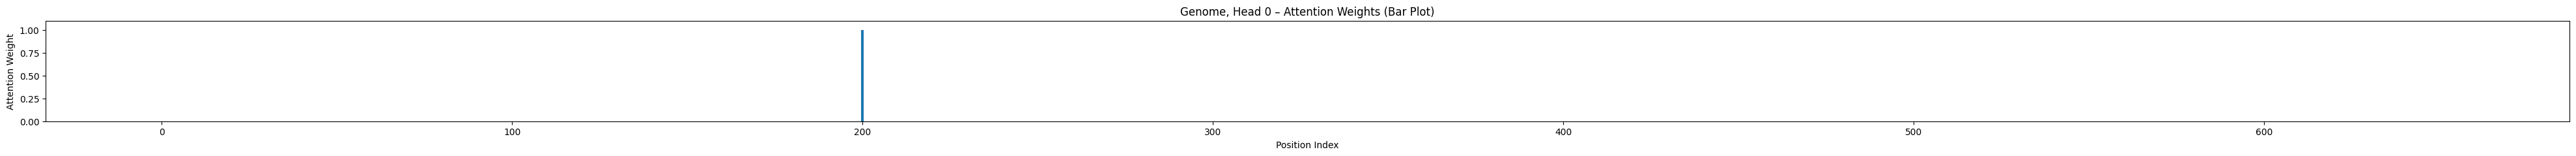

 big attn scores: [1.]
 corresponding index: [200]


ValueError: invalid literal for int() with base 10: 'CP136842.1'

In [6]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/all_AMP_SM_data_train/MDLM_MTR_fix_cls_wo_pad/all_data_best_R2_epoch_13.pth'  # 这个权重在所有的 MIC data 上训练过
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['#002']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'ApexOracle_3.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, cls_outputs, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')
    print(f'cls:{cls_outputs}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Genome, Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    annotation_found_flag = False
    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain.replace('-','_') in annotation_file.name:
            annotation_found_flag = True
            break

    if not annotation_found_flag:
        print(f'genome annotation for {strain} not found')
        exit(1)

    attented_products = []
    attented_genes = []
    contig_lengths = []
    current_contig_id = 0
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        config_id = int(seq_record.id.split('_')[-1])
        print(f' config_id:{seq_record.id}')
        if config_id != current_contig_id:
            current_contig_id = config_id
            contig_lengths.append(len(seq_record.seq))

        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if config_id > 1:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0] - np.array(contig_lengths).sum(), big_attn_gene_range[1] - np.array(contig_lengths).sum()
                    else:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0], big_attn_gene_range[1]
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')  # feature.qualifiers.get('gene / product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
                        genes = feature.qualifiers.get('gene')  # feature.qualifiers.get('gene / product')
                        if genes is not None:
                            for gene in genes:
                                if 'hypothetical' not in gene:
                                    attented_genes.append(gene)
                        else:
                            attented_genes.append('None')
    print(f" attended products:\n{attented_products}")
    print(f" attended genes:\n{attented_genes}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Text, Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0].replace('-', '_') in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        # text = text.replace(file_name.replace('_', ' ').replace('BAA ', 'BAA-'), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
print(f'Text file loaded:{str(text_file_path)}')
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

#### ApexOracle-12 对于 BAA-3197 耐药性解释

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:02<00:00, 390.76it/s]


mic:tensor([14.])
cls:tensor([0.4863])


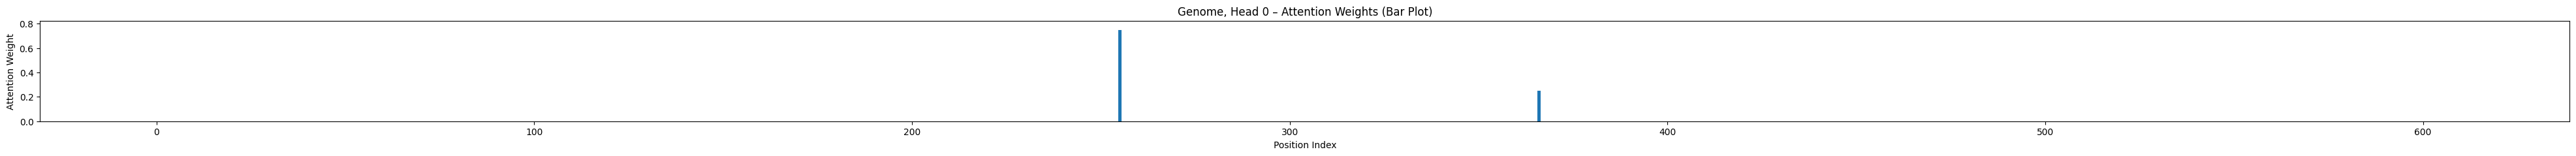

 big attn scores: [0.75 0.25]
 corresponding index: [255 366]
 config_id:assembly_cedbec140e354d0a_1
 config_id:assembly_cedbec140e354d0a_2
 config_id:assembly_cedbec140e354d0a_3
 attended products:
['DUF3275 family protein', 'DUF932 domain-containing protein', 'DUF3577 domain-containing protein', 'GTPase', 'uridylate kinase', 'ABC transporter substrate-binding protein', 'quorum-sensing transcriptional repressor QscR', 'sterol desaturase family protein', 'fatty acid desaturase', '2OG-Fe(II) oxygenase', 'penicillin acylase family protein', 'glutathione S-transferase']
 attended genes:
['None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'qscR', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None']


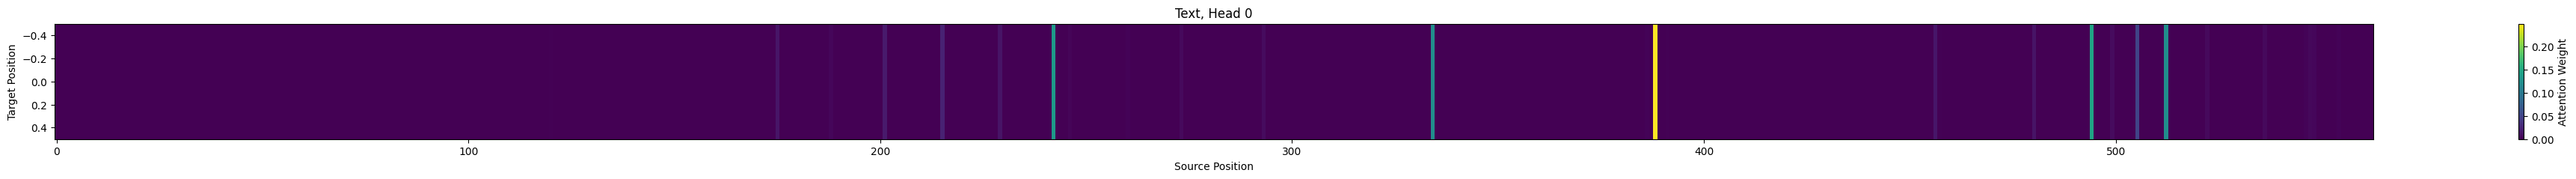

Text file loaded:/data2/tianang/projects/Synergy/DataPrepare/Data/Text_Description/ATCC/Text/Pseudomonas_aeruginosa_ATCC_BAA_3197.txt


/tmp/ipykernel_2668758/3011556072.py:160: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [12]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/all_AMP_SM_data_train/MDLM_MTR_fix_cls_wo_pad/all_data_best_R2_epoch_13.pth'  # 这个权重在所有的 MIC data 上训练过
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['BAA-3197']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'ApexOracle_12.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, cls_outputs, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')
    print(f'cls:{cls_outputs}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Genome, Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    annotation_found_flag = False
    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain.replace('-','_') in annotation_file.name:
            annotation_found_flag = True
            break

    if not annotation_found_flag:
        print(f'genome annotation for {strain} not found')
        exit(1)

    attented_products = []
    attented_genes = []
    contig_lengths = []
    current_contig_id = 0
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        config_id = int(seq_record.id.split('_')[-1])
        print(f' config_id:{seq_record.id}')
        if config_id != current_contig_id:
            current_contig_id = config_id
            contig_lengths.append(len(seq_record.seq))

        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if config_id > 1:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0] - np.array(contig_lengths).sum(), big_attn_gene_range[1] - np.array(contig_lengths).sum()
                    else:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0], big_attn_gene_range[1]
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')  # feature.qualifiers.get('gene / product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
                        genes = feature.qualifiers.get('gene')  # feature.qualifiers.get('gene / product')
                        if genes is not None:
                            for gene in genes:
                                if 'hypothetical' not in gene:
                                    attented_genes.append(gene)
                        else:
                            attented_genes.append('None')
    print(f" attended products:\n{attented_products}")
    print(f" attended genes:\n{attented_genes}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Text, Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0].replace('-', '_') in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        # text = text.replace(file_name.replace('_', ' ').replace('BAA ', 'BAA-'), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
print(f'Text file loaded:{str(text_file_path)}')
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

#### ApexOracle-12 对于 PAO1(ATCC 47085) 耐药性解释

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:02<00:00, 371.32it/s]


mic:tensor([129.])
cls:tensor([0.4727])


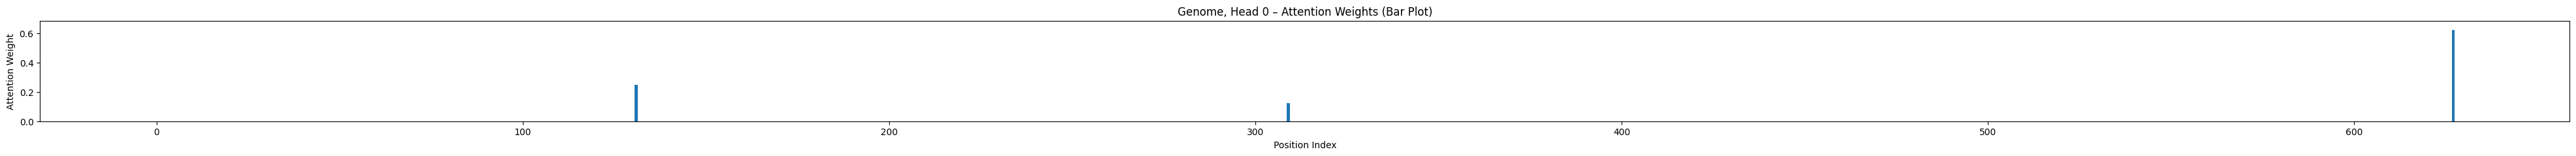

 big attn scores: [0.25  0.125 0.625]
 corresponding index: [131 309 627]
 config_id:assembly_a6462b6cc7da4347_1
 config_id:assembly_a6462b6cc7da4347_2
 config_id:assembly_a6462b6cc7da4347_3
 attended products:
['MFS transporter', 'clavaminate synthase family protein', 'asparagine synthetase B', 'class I adenylate-forming enzyme family protein', 'class I SAM-dependent methyltransferase', '2-isopropylmalate synthase', 'phytanoyl-CoA dioxygenase family protein', 'alpha/beta fold hydrolase', 'RhuM family protein', 'RhuM family protein', 'restriction endonuclease subunit S', 'class I SAM-dependent DNA methyltransferase', 'helix-turn-helix domain-containing protein', 'MerR family transcriptional regulator', 'integration host factor subunit alpha', 'phenylalanine--tRNA ligase subunit beta', 'membrane protein insertase YidC', 'ribonuclease P protein component', '50S ribosomal protein L34']
 attended genes:
['None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'rhuM', 'rhuM'

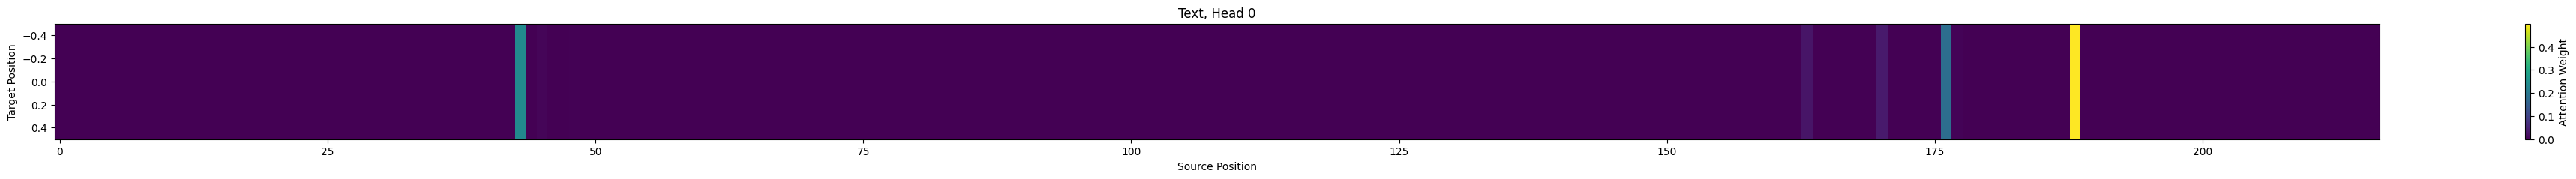

Text file loaded:/data2/tianang/projects/Synergy/DataPrepare/Data/Text_Description/ATCC/Text/Pseudomonas_aeruginosa_ATCC_47085.txt


/tmp/ipykernel_2668758/2651570315.py:160: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [15]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/all_AMP_SM_data_train/MDLM_MTR_fix_cls_wo_pad/all_data_best_R2_epoch_13.pth'  # 这个权重在所有的 MIC data 上训练过
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['47085']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'ApexOracle_12.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, cls_outputs, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')
    print(f'cls:{cls_outputs}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Genome, Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    annotation_found_flag = False
    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain.replace('-','_') in annotation_file.name:
            annotation_found_flag = True
            break

    if not annotation_found_flag:
        print(f'genome annotation for {strain} not found')
        exit(1)

    attented_products = []
    attented_genes = []
    contig_lengths = []
    current_contig_id = 0
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        config_id = int(seq_record.id.split('_')[-1])
        print(f' config_id:{seq_record.id}')
        if config_id != current_contig_id:
            current_contig_id = config_id
            contig_lengths.append(len(seq_record.seq))

        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if config_id > 1:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0] - np.array(contig_lengths).sum(), big_attn_gene_range[1] - np.array(contig_lengths).sum()
                    else:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0], big_attn_gene_range[1]
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')  # feature.qualifiers.get('gene / product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
                        genes = feature.qualifiers.get('gene')  # feature.qualifiers.get('gene / product')
                        if genes is not None:
                            for gene in genes:
                                if 'hypothetical' not in gene:
                                    attented_genes.append(gene)
                        else:
                            attented_genes.append('None')
    print(f" attended products:\n{attented_products}")
    print(f" attended genes:\n{attented_genes}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Text, Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0].replace('-', '_') in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        # text = text.replace(file_name.replace('_', ' ').replace('BAA ', 'BAA-'), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
print(f'Text file loaded:{str(text_file_path)}')
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

#### ApexOracle-12 对于 PA14 (ATCC #002) 耐药性解释

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:02<00:00, 380.68it/s]


mic:tensor([120.])
cls:tensor([0.4727])


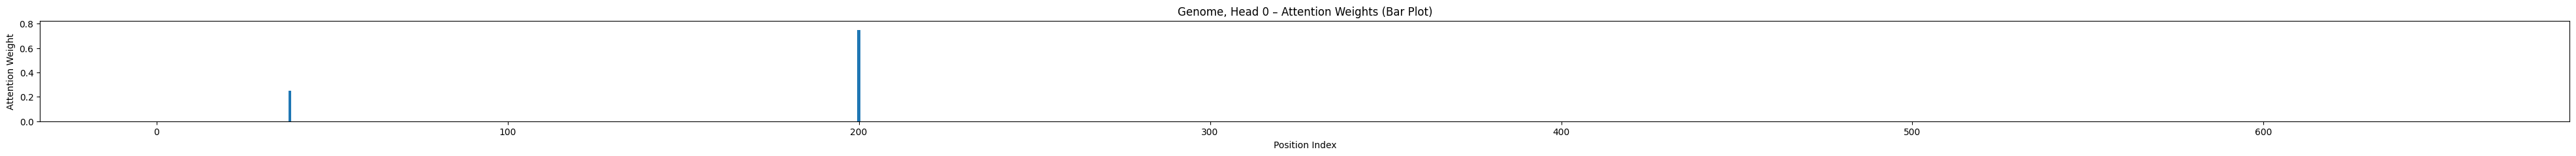

 big attn scores: [0.25 0.75]
 corresponding index: [ 38 200]


ValueError: invalid literal for int() with base 10: 'CP136842.1'

In [5]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/all_AMP_SM_data_train/MDLM_MTR_fix_cls_wo_pad/all_data_best_R2_epoch_13.pth'  # 这个权重在所有的 MIC data 上训练过
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['#002']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'ApexOracle_12.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, cls_outputs, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')
    print(f'cls:{cls_outputs}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Genome, Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    annotation_found_flag = False
    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain.replace('-','_') in annotation_file.name:
            annotation_found_flag = True
            break

    if not annotation_found_flag:
        print(f'genome annotation for {strain} not found')
        exit(1)

    attented_products = []
    attented_genes = []
    contig_lengths = []
    current_contig_id = 0
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        config_id = int(seq_record.id.split('_')[-1])
        print(f' config_id:{seq_record.id}')
        if config_id != current_contig_id:
            current_contig_id = config_id
            contig_lengths.append(len(seq_record.seq))

        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if config_id > 1:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0] - np.array(contig_lengths).sum(), big_attn_gene_range[1] - np.array(contig_lengths).sum()
                    else:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0], big_attn_gene_range[1]
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')  # feature.qualifiers.get('gene / product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
                        genes = feature.qualifiers.get('gene')  # feature.qualifiers.get('gene / product')
                        if genes is not None:
                            for gene in genes:
                                if 'hypothetical' not in gene:
                                    attented_genes.append(gene)
                        else:
                            attented_genes.append('None')
    print(f" attended products:\n{attented_products}")
    print(f" attended genes:\n{attented_genes}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Text, Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0].replace('-', '_') in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        # text = text.replace(file_name.replace('_', ' ').replace('BAA ', 'BAA-'), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
print(f'Text file loaded:{str(text_file_path)}')
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

### ApexOracle-18 对于 BAA-3170 耐药性解释

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:02<00:00, 415.96it/s]


mic:tensor([13.1875])
cls:tensor([0.5117])


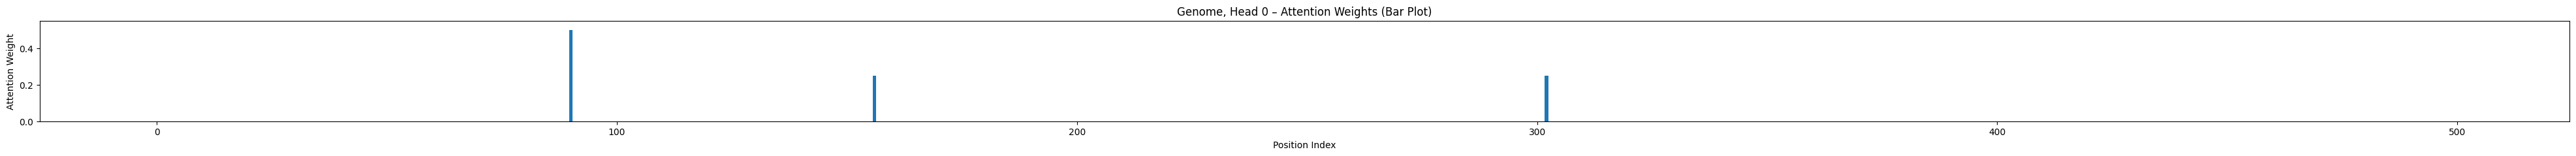

 big attn scores: [0.5        0.24999994 0.25      ]
 corresponding index: [ 90 156 302]
 config_id:assembly_5047e59f2cf34fc6_1
 config_id:assembly_5047e59f2cf34fc6_2
 config_id:assembly_5047e59f2cf34fc6_3
 config_id:assembly_5047e59f2cf34fc6_4
 config_id:assembly_5047e59f2cf34fc6_5
 attended products:
['glucose-1-phosphate thymidylyltransferase RfbA', 'dTDP-4-dehydrorhamnose 3,5-epimerase', 'capsular polysaccharide biosynthesis protein', 'capsular biosynthesis protein', 'DUF957 domain-containing protein', 'DUF5983 family protein', 'type IV toxin-antitoxin system cytoskeleton-binding toxin CbtA', 'type IV toxin-antitoxin system cytoskeleton bundling-enhancing antitoxin CbeA', 'DUF987 domain-containing protein', 'RadC family protein', 'antirestriction protein', 'DUF932 domain-containing protein', 'oxalyl-CoA decarboxylase', 'transporter YfdV', 'CoA:oxalate CoA-transferase', 'acid-sensing system histidine kinase EvgS', 'acid-sensing system DNA-binding response regulator EvgA', 'multidrug

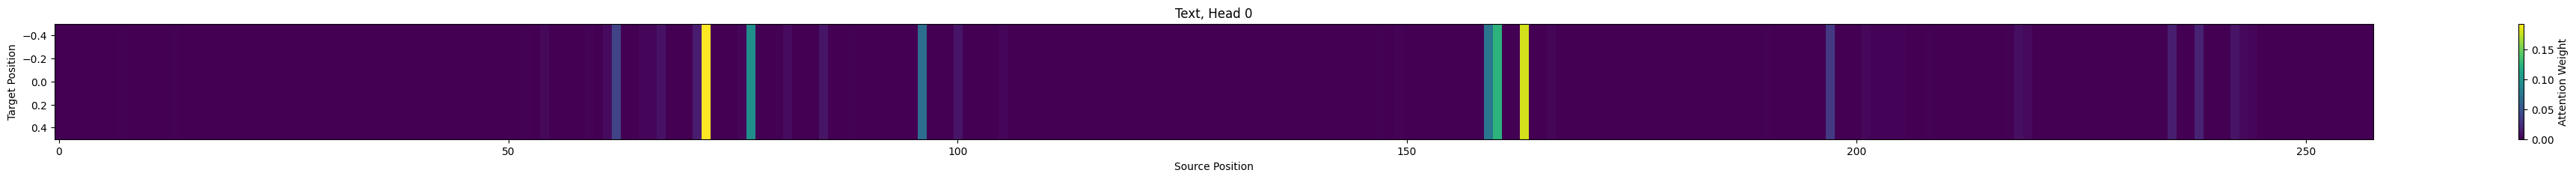

Text file loaded:/data2/tianang/projects/Synergy/DataPrepare/Data/Text_Description/ATCC/Text/Escherichia_coli_ATCC_BAA_3170.txt


/tmp/ipykernel_2668758/394284951.py:160: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [11]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/all_AMP_SM_data_train/MDLM_MTR_fix_cls_wo_pad/all_data_best_R2_epoch_13.pth'  # 这个权重在所有的 MIC data 上训练过
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['BAA-3170']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'ApexOracle_18.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, cls_outputs, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')
    print(f'cls:{cls_outputs}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Genome, Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    annotation_found_flag = False
    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain.replace('-','_') in annotation_file.name:
            annotation_found_flag = True
            break

    if not annotation_found_flag:
        print(f'genome annotation for {strain} not found')
        exit(1)

    attented_products = []
    attented_genes = []
    contig_lengths = []
    current_contig_id = 0
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        config_id = int(seq_record.id.split('_')[-1])
        print(f' config_id:{seq_record.id}')
        if config_id != current_contig_id:
            current_contig_id = config_id
            contig_lengths.append(len(seq_record.seq))

        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if config_id > 1:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0] - np.array(contig_lengths).sum(), big_attn_gene_range[1] - np.array(contig_lengths).sum()
                    else:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0], big_attn_gene_range[1]
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')  # feature.qualifiers.get('gene / product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
                        genes = feature.qualifiers.get('gene')  # feature.qualifiers.get('gene / product')
                        if genes is not None:
                            for gene in genes:
                                if 'hypothetical' not in gene:
                                    attented_genes.append(gene)
                        else:
                            attented_genes.append('None')
    print(f" attended products:\n{attented_products}")
    print(f" attended genes:\n{attented_genes}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Text, Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0].replace('-', '_') in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        # text = text.replace(file_name.replace('_', ' ').replace('BAA ', 'BAA-'), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
print(f'Text file loaded:{str(text_file_path)}')
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

### ApexOracle-18 对于 11775 耐药性解释

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:02<00:00, 432.66it/s]


mic:tensor([62.5000])
cls:tensor([0.4980])


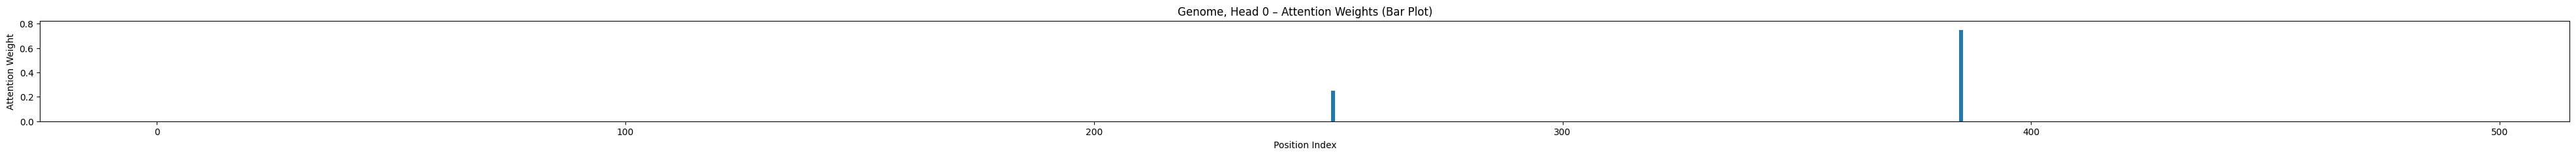

 big attn scores: [0.25 0.75]
 corresponding index: [251 385]
 config_id:assembly_80710acd3a7f402b_1
 config_id:assembly_80710acd3a7f402b_2
 attended products:
['YfjP family GTPase', 'WYL domain-containing protein', 'DUF905 family protein', 'DUF932 domain-containing protein', 'antirestriction protein', 'RadC family protein', 'DUF987 domain-containing protein', 'type IV toxin-antitoxin system YeeU family antitoxin', 'type IV toxin-antitoxin system cytoskeleton-binding toxin CbtA', 'DUF5983 family protein', 'DUF957 domain-containing protein', 'DUF4942 domain-containing protein', 'lysine decarboxylation/transport transcriptional activator CadC', 'N-acetylneuraminate synthase', 'GDSL-type esterase/lipase family protein', 'UDP-N-acetylglucosamine 2-epimerase', 'NeuE protein', 'alpha-2,8-polysialyltransferase family protein', 'capsular biosynthesis protein', 'capsular polysaccharide biosynthesis protein', '3-deoxy-manno-octulosonate cytidylyltransferase']
 attended genes:
['None', 'None', 'N

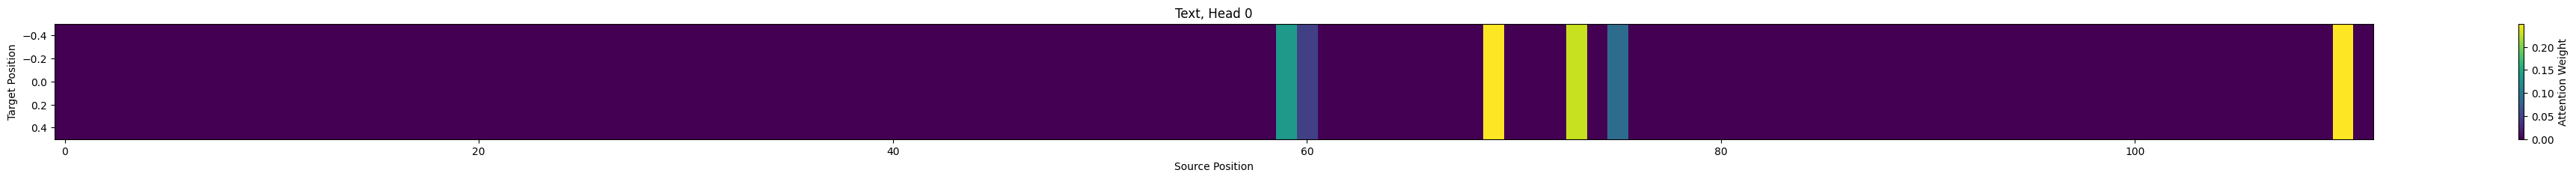

Text file loaded:/data2/tianang/projects/Synergy/DataPrepare/Data/Text_Description/ATCC/Text/Escherichia_coli_ATCC_11775.txt


/tmp/ipykernel_2668758/3501365875.py:160: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [13]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/all_AMP_SM_data_train/MDLM_MTR_fix_cls_wo_pad/all_data_best_R2_epoch_13.pth'  # 这个权重在所有的 MIC data 上训练过
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['11775']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'ApexOracle_18.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, cls_outputs, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')
    print(f'cls:{cls_outputs}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Genome, Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    annotation_found_flag = False
    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain.replace('-','_') in annotation_file.name:
            annotation_found_flag = True
            break

    if not annotation_found_flag:
        print(f'genome annotation for {strain} not found')
        exit(1)

    attented_products = []
    attented_genes = []
    contig_lengths = []
    current_contig_id = 0
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        config_id = int(seq_record.id.split('_')[-1])
        print(f' config_id:{seq_record.id}')
        if config_id != current_contig_id:
            current_contig_id = config_id
            contig_lengths.append(len(seq_record.seq))

        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if config_id > 1:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0] - np.array(contig_lengths).sum(), big_attn_gene_range[1] - np.array(contig_lengths).sum()
                    else:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0], big_attn_gene_range[1]
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')  # feature.qualifiers.get('gene / product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
                        genes = feature.qualifiers.get('gene')  # feature.qualifiers.get('gene / product')
                        if genes is not None:
                            for gene in genes:
                                if 'hypothetical' not in gene:
                                    attented_genes.append(gene)
                        else:
                            attented_genes.append('None')
    print(f" attended products:\n{attented_products}")
    print(f" attended genes:\n{attented_genes}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Text, Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0].replace('-', '_') in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        # text = text.replace(file_name.replace('_', ' ').replace('BAA ', 'BAA-'), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
print(f'Text file loaded:{str(text_file_path)}')
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))

#### ApexOracle-18 对于 BW25113 (ATCC #004) 耐药性解释

 loading text only embedding embeddings ... : 100%|██████████| 1079/1079 [00:07<00:00, 144.82it/s]


mic:tensor([16.3750])
cls:tensor([0.5195])


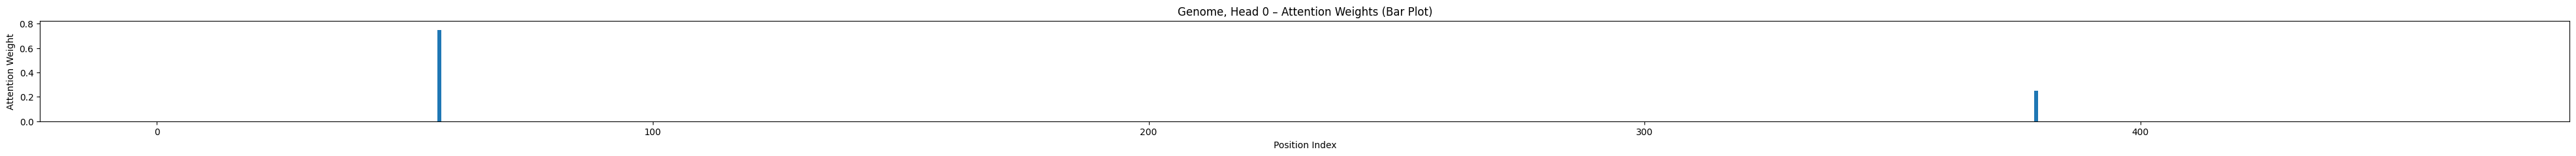

 big attn scores: [0.75 0.25]
 corresponding index: [ 57 379]
 config_id:CP009273.1
 attended products:
['IS5 transposase and trans-activator', 'DLP12 prophage; putative phage lysis protein', 'DLP12 prophage; putative lysozyme', 'DLP12 prophage; putative murein endopeptidase', 'DLP12 prophage; putative lipoprotein', 'DLP12 prophage; putative lipoprotein', 'DLP12 prophage; uncharacterized protein', 'DLP12 prophage; uncharacterized protein', 'DUF3950 family protein, DLP12 prophage', 'DLP12 prophage; DNA packaging protein', 'global transcriptional activator; DLP12 prophage', 'O-antigen ligase', 'lipopolysaccharide core biosynthesis', 'lipopolysaccharide core biosynthesis protein', 'lipopolysaccharide core biosynthesis protein', 'UDP-D-glucose:(galactosyl)lipopolysaccharide glucosyltransferase', 'UDP-D-galactose:(glucosyl)lipopolysaccharide- alpha-1,3-D-galactosyltransferase', 'UDP-D-galactose:(glucosyl)lipopolysaccharide-1, 6-D-galactosyltransferase', 'lipopolysaccharide core biosynthesis

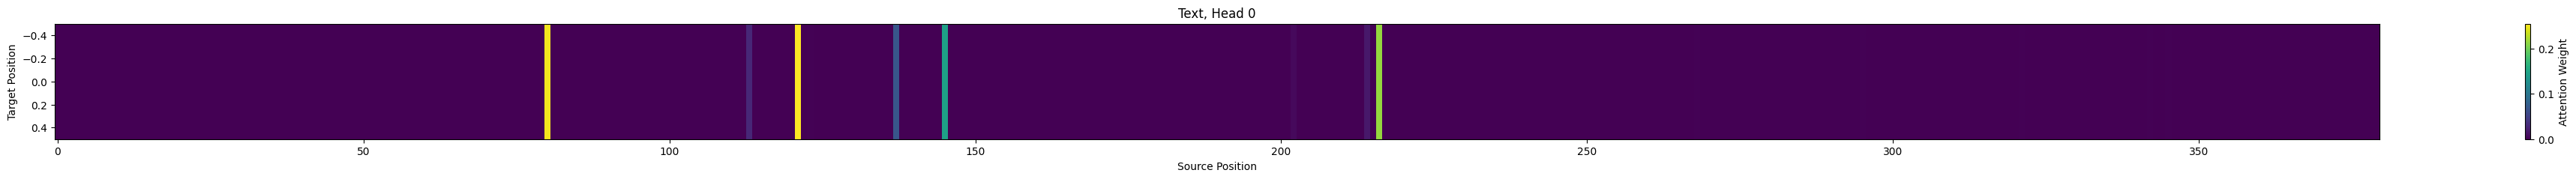

Text file loaded:/data2/tianang/projects/Synergy/DataPrepare/Data/Text_Description/ATCC/Text/Escherichia_coli_ATCC_#004.txt


/tmp/ipykernel_2559421/2035478939.py:160: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


In [3]:
show_log2 = True

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_non_pad_clean/noise_guidance_best_R2_all_peptide_epoch_13.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/all_AMP_SM_data_train/MDLM_MTR_fix_cls_wo_pad/all_data_best_R2_epoch_13.pth'  # 这个权重在所有的 MIC data 上训练过
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor_pad_no_mask/noise_guidance_best_R2_all_peptide_epoch_100.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/guidance_best_R2_all_peptide_epoch_12.pth'
# ckpt_path = '/data2/tianang/projects/Synergy/Checkpoints/genome_text_learnable_emb/guidance_regressor/noise_guidance_all_peptide_epoch_100_of_100.pth'

# 先读取 SELFIES 的文件
# guidance_method = 'noise'  # clean / noise
# strain_show_names = [r'P. aeruginosa BAA-3197']
strains = ['#004']
# length = '232'
# target_MICs = ['1', '1000']  # '1000' 表示 unconditional generation
# generate_mol_save_dir = Path('/data2/tianang/projects/discrete-diffusion-guidance/outputs/generated_mol_SELFIES')
file_path = current_directory / 'DataPrepare' / 'Data' / 'mol_visualize' / 'ApexOracle_18.txt'

model_name = "ibm-research/materials.selfies-ted"
tokenizer = AutoTokenizer.from_pretrained(model_name)

mic_regressor = MIC_regressor(config, ckpt_path, device)
mic_regressor.to(device)
mic_regressor.eval()

ax_labels = ['Guided', 'Unconditional']

colors = ["#F7CFE1", "#B49EDE"]  # , "#759ECD"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=2)

fractions = np.linspace(0, 1, len(ax_labels))
palette = [custom_cmap(f) for f in fractions]

for strain in strains:
    mic_list = []
    # for target_MIC in target_MICs:
    mic, cls_outputs, attn_genome, attn_text = get_mic(file_path, mic_regressor, tokenizer, strain)

    print(f'mic:{mic}')
    print(f'cls:{cls_outputs}')

    # attn_genome = attn_genome[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_genome.size(0)):
        arr = attn_genome[head].detach().cpu().numpy().flatten()  # (128,)
        plt.figure(figsize=(50, 2))
        plt.bar(range(len(arr)), arr, width=0.8)
        plt.title(f"Genome, Head {head} – Attention Weights (Bar Plot)")
        plt.xlabel("Position Index")
        plt.ylabel("Attention Weight")
        plt.ylim(0, arr.max() * 1.1)
        plt.show()

    # k=4
    # top_vals, top_idx = torch.topk(attn_genome[0][0], k)
    # print(f' top genome indexs:{top_idx+1}')
    # print(f' top genome vals:{top_vals}')

    big_attn_indexes = torch.where(attn_genome[0][0] > 0.05)[0].detach().cpu().numpy()
    print(f' big attn scores: {attn_genome[0][0][attn_genome[0][0] > 0.05].detach().cpu().numpy()}')
    print(f' corresponding index: {big_attn_indexes}')

    big_attn_gene_ranges = []
    for big_attn_index in big_attn_indexes:
        big_attn_gene_ranges.append([big_attn_index * 10000, big_attn_index * 10000 + 11000])

    annotation_found_flag = False
    genome_annotation_folder_path = current_directory / 'DataPrepare' / 'Data' / 'Genome_annotation'
    for annotation_file in genome_annotation_folder_path.iterdir():
        if strain.replace('-','_') in annotation_file.name:
            annotation_found_flag = True
            break

    if not annotation_found_flag:
        print(f'genome annotation for {strain} not found')
        exit(1)

    attented_products = []
    attented_genes = []
    contig_lengths = []
    current_contig_id = 0
    for seq_record in SeqIO.parse(annotation_file, "genbank"):
        config_id = int(seq_record.id.split('_')[-1]) if '_' in seq_record.id else int(seq_record.id.split('.')[-1])
        print(f' config_id:{seq_record.id}')
        if config_id != current_contig_id:
            current_contig_id = config_id
            contig_lengths.append(len(seq_record.seq))

        for feature in seq_record.features:
            if feature.type == 'CDS':
                for big_attn_gene_range in big_attn_gene_ranges:
                    if config_id > 1:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0] - np.array(contig_lengths).sum(), big_attn_gene_range[1] - np.array(contig_lengths).sum()
                    else:
                        big_attn_gene_range_low_bound, big_attn_gene_range_high_bound = big_attn_gene_range[0], big_attn_gene_range[1]
                    if int(feature.location.start) > big_attn_gene_range[0] and int(feature.location.end) < big_attn_gene_range[1]:
                        # print(f"\n index range:{big_attn_gene_range}")
                        # print(f" locus_tag: {feature.qualifiers.get('locus_tag')}")
                        # print(f" product: {feature.qualifiers.get('product')}")

                        products = feature.qualifiers.get('product')  # feature.qualifiers.get('gene / product')
                        if products is not None:
                            for product in products:
                                if 'hypothetical' not in product:
                                    attented_products.append(product)
                        genes = feature.qualifiers.get('gene')  # feature.qualifiers.get('gene / product')
                        if genes is not None:
                            for gene in genes:
                                if 'hypothetical' not in gene:
                                    attented_genes.append(gene)
                        else:
                            attented_genes.append('None')
    print(f" attended products:\n{attented_products}")
    print(f" attended genes:\n{attented_genes}")

    # attn_text = attn_text[0]  # 形状 (num_heads, tgt_len, src_len)

    # 可视化每个头
    for head in range(attn_text.size(0)):
        plt.figure(figsize=(50, 2))
        plt.title(f"Text, Head {head}")
        plt.imshow(attn_text[head].detach().cpu().numpy(), aspect='auto')
        plt.xlabel("Source Position")
        plt.ylabel("Target Position")
        plt.colorbar(label="Attention Weight")
        plt.show()

    k = 10  # 要取最大的 10 个
    top_vals, top_idx = torch.topk(attn_text[0][0], k)  # 默认 largest=True, dim=0

    for text_file_path in (
            current_directory / 'DataPrepare' / 'Data' / 'Text_Description' / 'ATCC' / 'Text').iterdir():
        if strains[0].replace('-', '_') in text_file_path.name:
            break

    with open(text_file_path, 'r') as f:
        text = f.read()
        file_name = text_file_path.name.split('.')[0]
        text = text.replace(file_name.replace('_', ' ').replace('subsp', 'subsp.'), 'This strain')
        # text = text.replace(file_name.replace('_', ' ').replace('BAA ', 'BAA-'), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        text = text.replace(file_name.replace('_', ' '), 'This strain')  # 把所有的 strain 的名字都用 This strain 代替
        # ATCC_ID = file_name.replace('_', ' ').split('ATCC')[-1].strip()

tokenizer = AutoTokenizer.from_pretrained("YBXL/Med-LLaMA3-8B")
input_ids = tokenizer(text, return_tensors="pt").input_ids[0]
ids_list = input_ids.tolist()
input_text = tokenizer.convert_ids_to_tokens(ids_list)
print(f'Text file loaded:{str(text_file_path)}')
for word in input_text:
    if 'Ġ' in word:
        word = word.replace('Ġ', ' ')

attn_text = attn_text[0][0].detach().cpu()
scores_np = attn_text.numpy()
min_v, max_v = scores_np.min(), scores_np.max()
norm_scores = (scores_np - min_v) / (max_v - min_v + 1e-8)  # 防止除零

# 2. 定义一个小函数：根据在 [0,1] 中的注意力值，输出对应的背景色（这里用 matplotlib 的 colormap）
cmap = matplotlib.cm.get_cmap('Reds')  # 选择一种红色渐变


def score_to_hex(score):
    """把 0~1 的 float 映射到一个 HEX 颜色，比如 #FFCCCC."""
    rgba = cmap(score)  # 返回 RGBA 四元组
    rgb = tuple(int(x * 255) for x in rgba[:3])
    return '#%02x%02x%02x' % rgb  # 转为十六进制字符串


# 3. 生成 HTML 片段
html_pieces = []
for token, ns in zip(input_text, norm_scores):
    color = score_to_hex(ns)
    # 把 token 包裹在一个 <span> 里，用行内样式指定背景色
    cleaned_token = token.replace("Ġ", " ").replace("ĊĊ", "<br><br>")
    html_pieces.append(
        f'<span style="background-color:{color}; padding:2px; margin:1px; border-radius:2px;">{cleaned_token}</span>'
    )

html_str = ''.join(html_pieces)  # 拼成一句 HTML
display(HTML(html_str))